In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso


import classification_rf

from importlib import reload
reload(classification_rf)

from classification_rf import RandomForestClassifier621

np.random.seed(24)

import rf_wrapper_functions as rfwrap
from collections import namedtuple
Dataset = namedtuple('Dataset', ['X_train', 'X_test', 'y_train', 'y_test'])
Params = namedtuple('Params', ['min_samples_leaf', 'max_features', 'max_depth', 'force_label_split', 'oob_score'])


In [2]:
from sklearn.impute import SimpleImputer

#import Cleveland Data
processed_cleveland_data = pd.read_csv("Processed Data/processed.cleveland.data", delimiter=",", na_values=["?"], header = None).to_numpy()
processed_cleveland_data = np.delete(processed_cleveland_data, [11,12], axis=1)
imputer = SimpleImputer(strategy="median")
cleveland = imputer.fit_transform(processed_cleveland_data)

#add label column
cleveland = np.insert(cleveland, -1, [0]*len(cleveland), axis = 1)

processed_hungarian_data = pd.read_csv("Processed Data/processed.hungarian.data", delimiter=",", na_values=["?"], header = None).to_numpy()
processed_hungarian_data = np.delete(processed_hungarian_data, [11,12], axis=1)
imputer = SimpleImputer(strategy="median")
hungary = imputer.fit_transform(processed_hungarian_data)
#add label column
hungary = np.insert(hungary, -1, [1]*len(hungary), axis = 1)

processed_switzerland_data = pd.read_csv("Processed Data/processed.switzerland.data", delimiter=",", na_values=["?"], header = None).to_numpy()
processed_switzerland_data = np.delete(processed_switzerland_data, [11,12], axis=1)
imputer = SimpleImputer(strategy="median")
switzerland = imputer.fit_transform(processed_switzerland_data)
#add label column
switzerland = np.insert(switzerland, -1, [2]*len(switzerland), axis = 1)

processed_va_data = pd.read_csv("Processed Data/processed.va.data", delimiter=",", na_values=["?"], header = None).to_numpy()
processed_va_data = np.delete(processed_va_data, [11,12], axis=1)
imputer = SimpleImputer(strategy="median")
va = imputer.fit_transform(processed_va_data)
#add label column
va = np.insert(va, -1, [3]*len(va), axis = 1)

#data = np.vstack((processed_cleveland_data, processed_hungarian_data, processed_switzerland_data, processed_va_data))
data = np.vstack((cleveland, hungary, switzerland, va))

In [37]:
X = data[:,0:-1]
y = data[:,-1]
y[y != 0] = 1
y = y.astype(int)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

mask_2_train = X_train[:, -1] == 2
X_s2   = X_train[mask_2_train];  y_s2   = y_train[mask_2_train]
X_rest = X_train[~mask_2_train]; y_rest = y_train[~mask_2_train]

# Current counts
n_class1 = (y_s2 == 1).sum()
n_class0 = (y_s2 == 0).sum()
print(f"Study 2 before ROS: class_0={n_class0}, class_1={n_class1}, ratio={n_class0/(n_class0+n_class1):.2f}")

# Target: class_0 = 25% of total → if class_1 stays fixed:
# n_class0_target / (n_class0_target + n_class1) = 0.25
# → n_class0_target = n_class1 * (0.25 / 0.75)
n_class0_target = int(n_class1 * (0.25 / 0.75))

if n_class0_target <= n_class0:
    print(f"Class 0 already at or above 25% ({n_class0/(n_class0+n_class1):.2f}), skipping ROS")
    X_s2_res, y_s2_res = X_s2, y_s2
else:
    ros = RandomOverSampler(
        sampling_strategy={0: n_class0_target, 1: n_class1},  # class_1 unchanged
        random_state=24
    )
    X_s2_res, y_s2_res = ros.fit_resample(X_s2, y_s2)

n0 = (y_s2_res == 0).sum()
n1 = (y_s2_res == 1).sum()
print(f"Study 2 after ROS:  class_0={n0}, class_1={n1}, ratio={n0/(n0+n1):.2f}")

# ── Recombine study 2 resampled with rest, then balance globally ──────────────
X_combined = np.concatenate([X_rest, X_s2_res], axis=0)
y_combined = np.concatenate([y_rest, y_s2_res], axis=0)

n0 = (y_combined == 0).sum()
n1 = (y_combined == 1).sum()
print(f"Before global ROS: class_0={n0}, class_1={n1}")

# Balance to majority class count
target = max(n0, n1)
ros_global = RandomOverSampler(
    sampling_strategy={0: target, 1: target},
    random_state=24
)
X_res, y_res = ros_global.fit_resample(X_combined, y_combined)

n0_res = (y_res == 0).sum()
n1_res = (y_res == 1).sum()
print(f"After global ROS:  class_0={n0_res}, class_1={n1_res}")

# Per-source breakdown after rebalancing
for s in np.unique(X_res[:, -1]):
    mask = X_res[:, -1] == s
    n0s = ((y_res[mask]) == 0).sum()
    n1s = ((y_res[mask]) == 1).sum()
    print(f"  Study {int(s)}: class_0={n0s}, class_1={n1s}, ratio_0={n0s/(n0s+n1s):.2f}")

# Fresh train/test split on fully rebalanced data
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=24
)
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

Study 2 before ROS: class_0=6, class_1=93, ratio=0.06
Study 2 after ROS:  class_0=31, class_1=93, ratio=0.25
Before global ROS: class_0=355, class_1=406
After global ROS:  class_0=406, class_1=406
  Study 0: class_0=146, class_1=114, ratio_0=0.56
  Study 1: class_0=175, class_1=81, ratio_0=0.68
  Study 2: class_0=36, class_1=93, ratio_0=0.28
  Study 3: class_0=49, class_1=118, ratio_0=0.29

Train size: 649, Test size: 163


In [54]:
#Upscaling block
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(sampling_strategy={0: 1000, 1: 1000}, random_state=24)
# sampling_strategy dict sets the TARGET count per class

X_res, y_res = ros.fit_resample(X_train, y_train)

#X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=24)

source_means = [
np.mean(y_res[X_res[:,-1] == 0]),
np.mean(y_res[X_res[:,-1] == 1]),
np.mean(y_res[X_res[:,-1] == 2]),
np.mean(y_res[X_res[:,-1] == 3])
]
print(source_means)
print(np.shape(y_res[X_res[:,-1] == 2]))


[np.float64(0.432), np.float64(0.31781701444622795), np.float64(0.7038216560509554), np.float64(0.7100456621004566)]
(314,)


Depth 0 Seed 24: preds=[0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1.], true=[0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1]
Depth 1 Seed 24: preds=[0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1.], true=[0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1]
Depth 2 Seed 24: preds=[0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1.], true=[0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1]
Depth 3 Seed 24: preds=[0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1.], true=[0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1]
Depth 4 Seed 24: preds=[0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1.], true=[0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1]
Depth 5 Seed 24: preds=[0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1.], true=[0 1 1 1 1 1 1 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1]
Depth 6 Seed 24: preds=[0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1

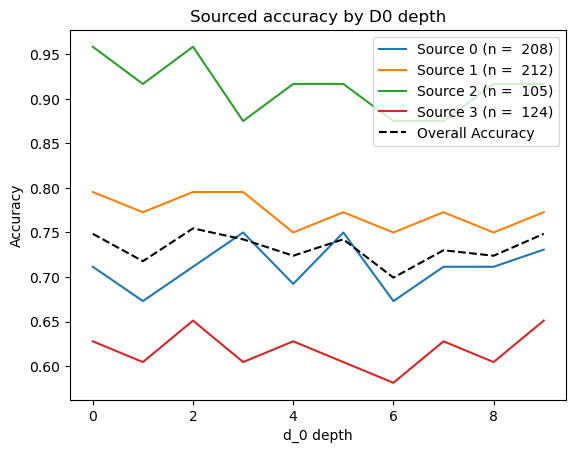

In [57]:
dataset = Dataset(X_train, X_test, y_train, y_test)
parameters = Params(3, "sqrt", 25, False, False)

accuracy_score, rf, source_score, source_size = rfwrap.forest_wrapper(n_estimators=100, depth=10, dataset=dataset, parameters=parameters, plot=True)


In [7]:
#Source Accuracy
depth = np.arange(15)

for i in range(len(source_score[0])):
    plt.plot(depth, source_score[:,i], label = f"Source {i} (n =  {source_size[i]})")

plt.plot(depth, accuracy_score, color = 'black', linestyle = "dashed", label = "total accuracy")
plt.xlabel('d_0 depth')
plt.ylabel('R^2 accuracy')
plt.legend()
#plt.ylim(0,1)
plt.title("Sourced accuracy on Lasso trimmed Data by D0 depth")

NameError: name 'source_score' is not defined

In [ ]:
X_va = X_res[X[:,-1] == 0]
y_va = y_res[:,-1]
y_va[y_va != 0] = 1
y_va = y_va.astype(int)

print(np.shape(X_va))

X_va_train, X_va_test, y_va_train, y_va_test = train_test_split(X_va, y_va, test_size=0.2, random_state=0, stratify=X_va[:,-1])
source_data = Dataset(X_va_train, X_va_test, y_va_train, y_va_test)
accuracy_score, rf, source_score, source_size = rfwrap.forest_wrapper(n_estimators=100, depth=10, dataset=source_data, parameters=parameters)

predictions = rf[0].predict(X_va_test)

print(predictions, "\n", y_va_test)

print(rf[0].score(X_va_test, y_va_test))

(200, 12)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.] 
 [1 1 1 1 0 0 0 1 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1
 1 1 1]
0.75
